# ARIMA - Walmart Weekly Sales

Rebuilt to match `model_experiment_sarima.ipynb` and
`model_experiment_prophet.ipynb` -- same classes pattern, same fixes, same
30-series set, so all three statistical approaches are now genuinely
comparable for the first time.

**Fixes applied here (same issues as the earlier SARIMA rebuild, since the
old ARIMA notebook had the same bugs):**

1. **No target leakage.** `ArimaSeriesPreprocessor` never interpolates --
   raises if a series has any gap. Uses only the complete series in
   `tables/representative_series_v1.csv` (the same 30-series set Prophet and
   the rebuilt SARIMA notebook use).
2. **Pooled metrics, not averaged per-series metrics.** Every WMAE/MAE/RMSE
   here is computed once on concatenated predictions across all series, not
   averaged per-series numbers -- and `cv_wmae_std` is the std of the 3
   real fold-level pooled scores.
3. **Same 30 series as SARIMA and Prophet**, not the ad-hoc 300 the earlier
   version used -- that's what actually makes cross-model comparison valid.
4. **No leakage in order selection.** `OrderCalibrator` picks `(p,d,q)`
   once per series using only the earliest CV fold's training window, not
   the full pre-holdout history -- the same class of leakage SARIMA's
   rebuild fixed, just within a single notebook this time rather than
   across two.
5. **Holdout evaluated exactly once**, only for the CV-selected winner.
6. **Correct file naming.** `stage="tuning"`, output goes to
   `arima_representative_results.csv`, not `arima_final.csv`.

Four trials, mirroring both the earlier ARIMA/ARIMAX split and SARIMA's
wide-grid trial: no exogenous input (baseline), `IsHoliday` alone, the full
economic-regressor set (retesting the earlier ARIMAX finding under this
corrected, leakage-free methodology), and a wider order grid.


In [1]:
import sys
import time
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Make the project root importable when running the notebook from notebooks/
project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import mlflow

# If your package isn't named "src", change the imports below.
from src.walmart_forecasting.data import load_processed_data
from src.walmart_forecasting.paths import TABLES_DIR
from src.walmart_forecasting.validation import chronological_holdout, expanding_window_splits
from src.walmart_forecasting.experiment import (
    HOLIDAY_WEIGHT,
    NON_HOLIDAY_WEIGHT,
    CV_FOLDS,
    CV_VALIDATION_WEEKS,
    FINAL_HOLDOUT_WEEKS,
    DEFAULT_RANDOM_SEED,
    build_common_parameters,
    build_result_row,
    make_run_name,
)
from src.walmart_forecasting.tracking import mlflow_run

np.random.seed(DEFAULT_RANDOM_SEED)
print("Setup complete.")


/Users/chkhai/Documents/uni6/ml/walmart-store-sales-forecasting/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


## 0. Experiment configuration


In [2]:
ARCHITECTURE = "arima"
STAGE = "tuning"  # representative_series scope isn't a "final" leaderboard scope
FORECAST_STRATEGY = "local_per_series"
EVALUATION_SCOPE = "representative_series"
EXPERIMENT_NAME = "ARIMA_Training"  # one MLflow experiment per architecture

RESULTS_FILENAME = "arima_representative_results.csv"  # not "_final" -- representative scope only
SERIES_PATH = TABLES_DIR / "representative_series_v1.csv"  # shared with Prophet and SARIMA


## 1. Load processed data + the shared representative series


In [3]:
processed = load_processed_data()
merged_train = processed.train.copy()
merged_train["Date"] = pd.to_datetime(merged_train["Date"])
merged_train = merged_train.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

if not SERIES_PATH.exists():
    raise FileNotFoundError(
        f"{SERIES_PATH} not found -- run the Prophet notebook first (or any notebook using "
        "RepresentativeSeriesSelector.select_and_save), it builds this shared 30-series file."
    )

selected = pd.read_csv(SERIES_PATH)
selected_keys = list(zip(selected["Store"], selected["Dept"]))

print(f"Train rows: {len(merged_train):,}")
print(f"Loaded {len(selected_keys)} shared representative series from {SERIES_PATH.name}")
selected[["Store", "Dept", "total_sales", "n_weeks", "volume_tier"]]


Train rows: 421,570
Loaded 30 shared representative series from representative_series_v1.csv


,Store,Dept,total_sales,n_weeks,volume_tier
0,15,52,223257.76,143,low
1,35,83,357099.15,143,low
2,28,52,378310.35,143,low
3,33,74,51952.16,143,low
4,32,52,359356.63,143,low
5,3,21,177967.74,143,low
6,28,31,369504.14,143,low
7,30,98,458605.96,143,low
8,37,87,145869.61,143,low
9,7,31,257336.97,143,low


## 2. `ArimaSeriesPreprocessor`

Same principle as SARIMA's preprocessor: no interpolation, ever. Raises if
a series has any gap after reindexing to strict weekly frequency. Since
these series are pre-filtered to be complete by `RepresentativeSeriesSelector`,
this should never actually fire.


In [4]:
class ArimaSeriesPreprocessor:
    """Builds a strict-weekly-frequency series for one Store-Dept. Raises if any gap exists."""

    def __init__(self, exog_cols=None):
        self.exog_cols = list(exog_cols or [])

    def build(self, dataframe, store, dept, date_col="Date", value_col="Weekly_Sales"):
        series = (
            dataframe[(dataframe["Store"] == store) & (dataframe["Dept"] == dept)]
            .sort_values(date_col)
            .set_index(date_col)
            .asfreq("W-FRI")
        )

        if series[value_col].isna().any():
            raise ValueError(
                f"Store {store} Dept {dept} is not a complete series -- has gaps after "
                "reindexing. This preprocessor never interpolates; use only complete series."
            )

        series["IsHoliday"] = series["IsHoliday"].astype(float)
        series["Store"] = store
        series["Dept"] = dept

        return series.reset_index()


## 3. Weighted MAE (pooled)

Same signature and intent as the Prophet/SARIMA notebooks' versions.


In [5]:
def weighted_mae(y_true, y_pred, is_holiday):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weights = np.where(np.asarray(is_holiday, dtype=bool), HOLIDAY_WEIGHT, NON_HOLIDAY_WEIGHT)
    return float(np.average(np.abs(y_true - y_pred), weights=weights))


## 4. `OrderCalibrator`

Selects one fixed `(p,d,q)` per series via a small AICc grid search, using
**only the earliest CV fold's training window** -- the only data
legitimately available before any fold begins. The same fixed order is
reused when refitting coefficients on each fold's own training data and on
the holdout; only the order *structure* is frozen early.


In [6]:
class OrderCalibrator:
    """Selects one (p,d,q) per series, using only a given calibration window."""

    def __init__(self, order_grid):
        self.order_grid = order_grid

    def calibrate(self, calibration_values, calibration_exog=None):
        best_order, best_score = None, np.inf

        for order in self.order_grid:
            try:
                fitted = ARIMA(
                    calibration_values,
                    exog=calibration_exog,
                    order=order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit()
            except Exception:
                continue

            if fitted.aicc < best_score:
                best_order, best_score = order, fitted.aicc

        return best_order, best_score


## 5. `ArimaForecaster`

Fits/predicts one series given an already-chosen, fixed `(p,d,q)` -- this
class doesn't search for orders itself, it just fits coefficients for
whatever order `OrderCalibrator` decided.


In [7]:
class ArimaForecaster:
    """Fits/predicts a single ARIMA model for one series, given a fixed order."""

    def __init__(self, order, exog_cols=None):
        self.order = order
        self.exog_cols = list(exog_cols or [])
        self.model = None

    def fit(self, train_df, value_col="Weekly_Sales"):
        train_exog = train_df[self.exog_cols].values if self.exog_cols else None

        self.model = ARIMA(
            train_df[value_col].values,
            exog=train_exog,
            order=self.order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit()

        return self

    def predict(self, future_df):
        future_exog = future_df[self.exog_cols].values if self.exog_cols else None
        return self.model.forecast(steps=len(future_df), exog=future_exog)


## 6. Shared feature-set / preprocessing IDs


In [8]:
BASE_FEATURE_SET = "target_only_v1"
HOLIDAY_FEATURE_SET = "target_holiday_v1"
ECON_FEATURE_SET = "arimax_calendar_economic_v1"

BASE_PREPROCESSING = "statistical_target_only_v1"
HOLIDAY_PREPROCESSING = "statistical_target_holiday_v1"
ECON_PREPROCESSING = "statistical_target_exog_v1"


## 7. Trial runner

Same shape as SARIMA's `run_sarima_trial` and Prophet's `run_prophet_trial`
-- pools predictions per fold across all series, only touches holdout when
explicitly asked, stores `feature_set`/`preprocessing` directly on the
result.


In [9]:
def run_arima_trial(selected_keys, order_grid, exog_cols, label,
                     feature_set, preprocessing, do_cv=True, do_holdout=False):
    preprocessor = ArimaSeriesPreprocessor(exog_cols=exog_cols)
    calibrator = OrderCalibrator(order_grid=order_grid)

    fold_prediction_rows = defaultdict(list)
    holdout_prediction_rows = []
    orders_used = []
    total_fit_seconds = 0.0
    total_predict_seconds = 0.0

    for store, dept in selected_keys:
        try:
            series_df = preprocessor.build(merged_train, store, dept)
        except ValueError as exc:
            print(f"Skipping Store {store} Dept {dept}: {exc}")
            continue

        try:
            holdout_split = chronological_holdout(series_df, validation_weeks=FINAL_HOLDOUT_WEEKS)
            cv_splits = expanding_window_splits(
                holdout_split.train, n_splits=CV_FOLDS, validation_weeks=CV_VALIDATION_WEEKS
            )
        except ValueError:
            continue

        # Calibrate order ONCE per series, using only the earliest fold's training window.
        calibration_fold = cv_splits[0]
        calibration_exog = calibration_fold.train[exog_cols].values if exog_cols else None
        order, score = calibrator.calibrate(
            calibration_fold.train["Weekly_Sales"].values, calibration_exog=calibration_exog
        )

        if order is None:
            continue

        orders_used.append({"Store": store, "Dept": dept, "order": order, "aicc": score})

        if do_cv:
            for fold_index, fold in enumerate(cv_splits):
                forecaster = ArimaForecaster(order=order, exog_cols=exog_cols)

                fit_start = time.perf_counter()
                try:
                    forecaster.fit(fold.train)
                except Exception:
                    continue
                total_fit_seconds += time.perf_counter() - fit_start

                predict_start = time.perf_counter()
                yhat = forecaster.predict(fold.validation)
                total_predict_seconds += time.perf_counter() - predict_start

                fold_prediction_rows[fold_index].append(pd.DataFrame({
                    "Store": store, "Dept": dept, "Date": fold.validation["Date"].values,
                    "actual": fold.validation["Weekly_Sales"].values, "prediction": yhat,
                    "IsHoliday": fold.validation["IsHoliday"].values,
                }))

        if do_holdout:
            forecaster = ArimaForecaster(order=order, exog_cols=exog_cols)

            fit_start = time.perf_counter()
            try:
                forecaster.fit(holdout_split.train)
            except Exception:
                continue
            total_fit_seconds += time.perf_counter() - fit_start

            predict_start = time.perf_counter()
            yhat = forecaster.predict(holdout_split.validation)
            total_predict_seconds += time.perf_counter() - predict_start

            holdout_prediction_rows.append(pd.DataFrame({
                "Store": store, "Dept": dept, "Date": holdout_split.validation["Date"].values,
                "actual": holdout_split.validation["Weekly_Sales"].values, "prediction": yhat,
                "IsHoliday": holdout_split.validation["IsHoliday"].values,
            }))

    result = {
        "label": label,
        "exog_cols": exog_cols,
        "feature_set": feature_set,
        "preprocessing": preprocessing,
        "order_grid_size": len(order_grid),
        "fit_seconds": total_fit_seconds,
        "predict_seconds": total_predict_seconds,
        "series_count": len(selected_keys),
        "series_used": len(orders_used),
        "orders_used": pd.DataFrame(orders_used),
    }

    if do_cv:
        fold_wmaes = []
        for fold_index in sorted(fold_prediction_rows):
            pooled = pd.concat(fold_prediction_rows[fold_index], ignore_index=True)
            fold_wmaes.append(weighted_mae(pooled["actual"], pooled["prediction"], pooled["IsHoliday"]))
        result["cv_wmae_mean"] = float(np.mean(fold_wmaes))
        result["cv_wmae_std"] = float(np.std(fold_wmaes))
        result["fold_wmaes"] = fold_wmaes

    if do_holdout and holdout_prediction_rows:
        pooled_holdout = pd.concat(holdout_prediction_rows, ignore_index=True)
        result["holdout_wmae"] = weighted_mae(pooled_holdout["actual"], pooled_holdout["prediction"], pooled_holdout["IsHoliday"])
        result["holdout_mae"] = float(np.mean(np.abs(pooled_holdout["actual"] - pooled_holdout["prediction"])))
        result["holdout_rmse"] = float(np.sqrt(np.mean((pooled_holdout["actual"] - pooled_holdout["prediction"]) ** 2)))
        result["pooled_holdout_predictions"] = pooled_holdout

    summary_bits = []
    if do_cv:
        summary_bits.append(f"cv_wmae_mean={result['cv_wmae_mean']:,.1f}")
    if do_holdout:
        summary_bits.append(f"holdout_wmae={result['holdout_wmae']:,.1f}")
    print(f"[{label}] " + ", ".join(summary_bits) + f", fit={total_fit_seconds:.1f}s, series_used={result['series_used']}/{len(selected_keys)}")

    return result


## 8. Order grids


In [10]:
BASE_ORDER_GRID = [(p, d, q) for p in [0, 1, 2] for d in [0, 1] for q in [0, 1, 2]]
WIDE_ORDER_GRID = [(p, d, q) for p in [0, 1, 2, 3] for d in [0, 1, 2] for q in [0, 1, 2, 3]]

print(f"Base grid: {len(BASE_ORDER_GRID)} combos per series (once)")
print(f"Wide grid: {len(WIDE_ORDER_GRID)} combos per series (once)")


Base grid: 18 combos per series (once)
Wide grid: 48 combos per series (once)


## 9. Timing calibration -- run this before committing to the full loop


In [11]:
calib_start = time.perf_counter()
run_arima_trial(
    selected_keys[:3], order_grid=BASE_ORDER_GRID, exog_cols=[],
    label="calibration_probe", feature_set=BASE_FEATURE_SET, preprocessing=BASE_PREPROCESSING,
)
calib_seconds = time.perf_counter() - calib_start

per_series_seconds = calib_seconds / 3
est_trial_minutes = (per_series_seconds * len(selected_keys)) / 60
est_wide_minutes = est_trial_minutes * (len(WIDE_ORDER_GRID) / len(BASE_ORDER_GRID))
est_total_minutes = 3 * est_trial_minutes + est_wide_minutes  # A, B, C similar cost, D is wider

print(f"~{per_series_seconds:.1f}s per series (base grid, calibration + 3 CV folds)")
print(f"Estimated Trial A/B/C each: ~{est_trial_minutes:.1f} min")
print(f"Estimated Trial D (wide grid): ~{est_wide_minutes:.1f} min")
print(f"Estimated total for all 4 trials: ~{est_total_minutes:.1f} min")


[calibration_probe] cv_wmae_mean=615.7, fit=0.1s, series_used=3/3
~0.1s per series (base grid, calibration + 3 CV folds)
Estimated Trial A/B/C each: ~0.1 min
Estimated Trial D (wide grid): ~0.2 min
Estimated total for all 4 trials: ~0.4 min


## 10. Trial A: no exogenous input, base grid


In [12]:
trial_a = run_arima_trial(
    selected_keys, order_grid=BASE_ORDER_GRID, exog_cols=[],
    label="A_no_exog_base_grid", feature_set=BASE_FEATURE_SET, preprocessing=BASE_PREPROCESSING,
)


[A_no_exog_base_grid] cv_wmae_mean=2,268.3, fit=0.5s, series_used=30/30


## 11. Trial B: `IsHoliday` as exogenous input, base grid


In [13]:
trial_b = run_arima_trial(
    selected_keys, order_grid=BASE_ORDER_GRID, exog_cols=["IsHoliday"],
    label="B_isholiday_exog_base_grid", feature_set=HOLIDAY_FEATURE_SET, preprocessing=HOLIDAY_PREPROCESSING,
)


[B_isholiday_exog_base_grid] cv_wmae_mean=2,284.8, fit=0.7s, series_used=30/30


## 12. Trial C: full economic ARIMAX, base grid

Retests the earlier ARIMAX finding (economic regressors made things worse)
under this corrected, leakage-free methodology and the same 30 series as
SARIMA/Prophet -- a clean confirmation or refutation, not just a repeat.


In [14]:
ECONOMIC_REGRESSORS = ["IsHoliday", "Temperature", "Fuel_Price", "CPI", "Unemployment"]

trial_c = run_arima_trial(
    selected_keys, order_grid=BASE_ORDER_GRID, exog_cols=ECONOMIC_REGRESSORS,
    label="C_economic_arimax_base_grid", feature_set=ECON_FEATURE_SET, preprocessing=ECON_PREPROCESSING,
)


[C_economic_arimax_base_grid] cv_wmae_mean=2,445.0, fit=1.8s, series_used=30/30


## 13. Trial D: no exogenous input, wide grid


In [15]:
trial_d = run_arima_trial(
    selected_keys, order_grid=WIDE_ORDER_GRID, exog_cols=[],
    label="D_no_exog_wide_grid", feature_set=BASE_FEATURE_SET, preprocessing=BASE_PREPROCESSING,
)


[D_no_exog_wide_grid] cv_wmae_mean=2,898.8, fit=1.6s, series_used=30/30


## 14. Compare all trials, pick the winner by CV WMAE


In [16]:
trials = [trial_a, trial_b, trial_c, trial_d]

comparison = pd.DataFrame([
    {"trial": t["label"], "exog_cols": t["exog_cols"], "order_grid_size": t["order_grid_size"],
     "series_used": t["series_used"], "cv_wmae_mean": t["cv_wmae_mean"], "cv_wmae_std": t["cv_wmae_std"]}
    for t in trials
])
comparison.sort_values("cv_wmae_mean")


,trial,exog_cols,order_grid_size,series_used,cv_wmae_mean,cv_wmae_std
0,A_no_exog_base_grid,[],18,30,2268.346961,560.311666
1,B_isholiday_exog_base_grid,[IsHoliday],18,30,2284.783246,566.395979
2,C_economic_arimax_base_grid,"[IsHoliday, Temperature, Fuel_Price, CPI, Unem...",18,30,2444.954856,590.391332
3,D_no_exog_wide_grid,[],48,30,2898.828902,1408.886577


In [17]:
winner = min(trials, key=lambda t: t["cv_wmae_mean"])
print(f"Winner by CV WMAE: {winner['label']} (cv_wmae_mean={winner['cv_wmae_mean']:,.1f})")

FEATURE_SET = winner["feature_set"]
PREPROCESSING = winner["preprocessing"]
TRIAL_NAME = winner["label"].lower()

winner_order_grid = WIDE_ORDER_GRID if "wide" in winner["label"] else BASE_ORDER_GRID


Winner by CV WMAE: A_no_exog_base_grid (cv_wmae_mean=2,268.3)


## 15. Final holdout -- evaluated exactly once, only for the winner

Wrapped in the MLflow run context *before* fitting starts, so the logged
duration on DagsHub reflects real training time.


In [18]:
run_name = make_run_name(
    architecture=ARCHITECTURE,
    stage=STAGE,
    feature_set=FEATURE_SET,
    trial_name=TRIAL_NAME,
)

common_params = build_common_parameters(
    architecture=ARCHITECTURE,
    stage=STAGE,
    feature_set=FEATURE_SET,
    preprocessing=PREPROCESSING,
    evaluation_scope=EVALUATION_SCOPE,
    forecast_strategy=FORECAST_STRATEGY,
    series_count=len(selected_keys),
    random_seed=DEFAULT_RANDOM_SEED,
    extra_parameters={
        "exog_cols": winner["exog_cols"],
        "order_grid_size": winner["order_grid_size"],
        "order_selection_criterion": "aicc",
        "order_calibration_window": "earliest_cv_fold_training_only",
        "trials_compared": [t["label"] for t in trials],
    },
)

TABLES_DIR.mkdir(parents=True, exist_ok=True)
results_path = TABLES_DIR / RESULTS_FILENAME

with mlflow_run(
    experiment_name=EXPERIMENT_NAME,
    run_name=run_name,
    parameters=common_params,
    tags={"architecture": ARCHITECTURE, "stage": STAGE, "scope": EVALUATION_SCOPE, "trial": TRIAL_NAME},
) as run:

    holdout_only = run_arima_trial(
        selected_keys, order_grid=winner_order_grid, exog_cols=winner["exog_cols"],
        label=winner["label"] + "_final_holdout", feature_set=FEATURE_SET, preprocessing=PREPROCESSING,
        do_cv=False, do_holdout=True,
    )

    final_metrics = {
        "cv_wmae_mean": winner["cv_wmae_mean"],
        "cv_wmae_std": winner["cv_wmae_std"],
        "holdout_wmae": holdout_only["holdout_wmae"],
        "holdout_mae": holdout_only["holdout_mae"],
        "holdout_rmse": holdout_only["holdout_rmse"],
    }

    total_fit_seconds = winner["fit_seconds"] + holdout_only["fit_seconds"]
    total_predict_seconds = winner["predict_seconds"] + holdout_only["predict_seconds"]

    mlflow.log_metrics({**final_metrics, "fit_seconds": total_fit_seconds, "predict_seconds": total_predict_seconds})

    holdout_only["pooled_holdout_predictions"].to_csv(TABLES_DIR / "arima_holdout_predictions.csv", index=False)
    mlflow.log_artifact(str(TABLES_DIR / "arima_holdout_predictions.csv"))

print("\nFinal metrics (winner, evaluated once on holdout):")
for key, value in final_metrics.items():
    print(f"  {key}: {value:,.2f}")


Accessing as lchkh23

Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

[A_no_exog_base_grid_final_holdout] holdout_wmae=2,729.1, fit=0.2s, series_used=30/30
🏃 View run arima__tuning__target_only_v1__a_no_exog_base_grid__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/2/runs/b284bf18a86241e08e4fea61722e6187
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/2

Final metrics (winner, evaluated once on holdout):
  cv_wmae_mean: 2,268.35
  cv_wmae_std: 560.31
  holdout_wmae: 2,729.10
  holdout_mae: 2,651.22
  holdout_rmse: 6,744.45


## 16. Save to the shared representative-results CSV


In [19]:
result_row = build_result_row(
    architecture=ARCHITECTURE,
    run_name=run_name,
    stage=STAGE,
    tracker="mlflow",
    feature_set=FEATURE_SET,
    preprocessing=PREPROCESSING,
    evaluation_scope=EVALUATION_SCOPE,
    forecast_strategy=FORECAST_STRATEGY,
    series_count=len(selected_keys),
    metrics=final_metrics,
    fit_seconds=total_fit_seconds,
    predict_seconds=total_predict_seconds,
    notes=(
        f"ARIMA, winning config from 4 trials (IsHoliday exog, full economic ARIMAX, wide "
        f"grid ablations): {winner['label']}. Order chosen once per series via AICc, using "
        f"only the earliest CV fold's training window (no leakage). Holdout evaluated once. "
        f"Representative series, not full dataset."
    ),
)

results_row_df = pd.DataFrame([result_row])
if results_path.exists():
    existing = pd.read_csv(results_path)
    results_row_df = pd.concat([existing, results_row_df], ignore_index=True)
results_row_df.to_csv(results_path, index=False)
print(f"Saved winning result to {results_path.name}")


for trial in trials:
    if trial["label"] == winner["label"]:
        continue  # already logged above with the full run

    trial_run_name = make_run_name(
        architecture=ARCHITECTURE, stage=STAGE, feature_set=trial["feature_set"], trial_name=trial["label"].lower()
    )
    trial_params = build_common_parameters(
        architecture=ARCHITECTURE, stage=STAGE, feature_set=trial["feature_set"], preprocessing=trial["preprocessing"],
        evaluation_scope=EVALUATION_SCOPE, forecast_strategy=FORECAST_STRATEGY, series_count=len(selected_keys),
        extra_parameters={"exog_cols": trial["exog_cols"], "order_grid_size": trial["order_grid_size"]},
    )
    with mlflow_run(
        experiment_name=EXPERIMENT_NAME, run_name=trial_run_name, parameters=trial_params,
        tags={"architecture": ARCHITECTURE, "stage": STAGE, "trial": trial["label"].lower()},
    ):
        mlflow.log_metrics({
            "cv_wmae_mean": trial["cv_wmae_mean"], "cv_wmae_std": trial["cv_wmae_std"],
            "fit_seconds": trial["fit_seconds"], "predict_seconds": trial["predict_seconds"],
        })

print("Logged non-winning trials to MLflow (CV-only, no holdout).")


Saved winning result to arima_representative_results.csv


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run arima__tuning__target_holiday_v1__b_isholiday_exog_base_grid__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/2/runs/b630ee5e66cf4484a3f1f381ee6d0772
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/2


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run arima__tuning__arimax_calendar_economic_v1__c_economic_arimax_base_grid__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/2/runs/d9e11c0219fe42a5aa639df78faa9c28
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/2


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run arima__tuning__target_only_v1__d_no_exog_wide_grid__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/2/runs/50347f133dc2463bbb61d964266c881a
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/2
Logged non-winning trials to MLflow (CV-only, no holdout).


## 17. A few forecasts, visually


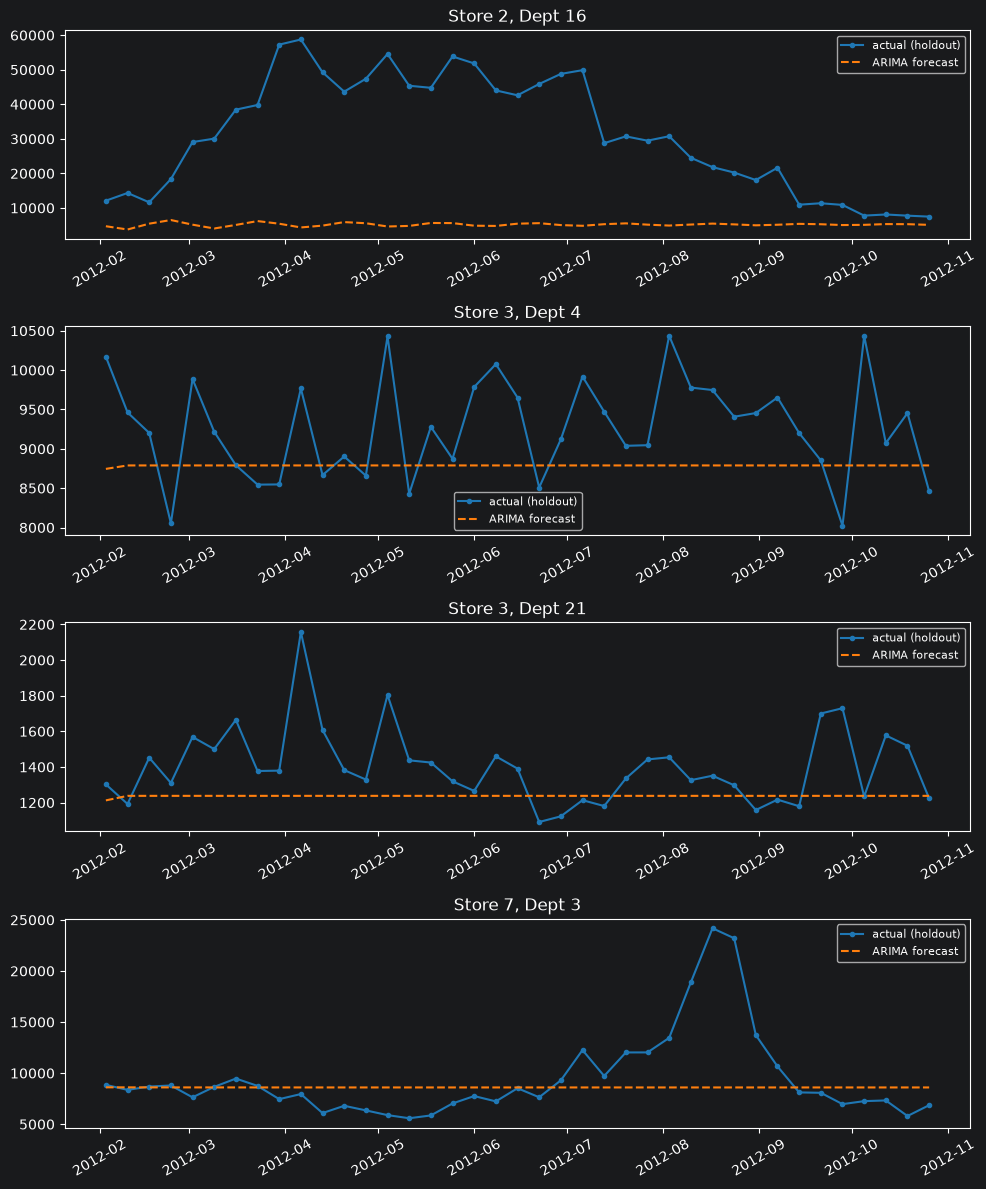

In [20]:
sample_series = holdout_only["pooled_holdout_predictions"].groupby(["Store", "Dept"])
sample_keys = list(sample_series.groups.keys())[:4]

fig, axes = plt.subplots(len(sample_keys), 1, figsize=(10, 3 * len(sample_keys)))
if len(sample_keys) == 1:
    axes = [axes]

for ax, key in zip(axes, sample_keys):
    subset = sample_series.get_group(key).sort_values("Date")
    ax.plot(subset["Date"], subset["actual"], label="actual (holdout)", color="tab:blue", marker="o", markersize=3)
    ax.plot(subset["Date"], subset["prediction"], label="ARIMA forecast", color="tab:orange", linestyle="--")
    ax.set_title(f"Store {key[0]}, Dept {key[1]}")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## 18. Takeaways & next steps

- These numbers are now directly comparable to both the rebuilt SARIMA
  notebook and Prophet -- same 30 series, same pooled-metric methodology,
  holdout spent once each.
- Check whether Trial C (full economic ARIMAX) still loses under this
  corrected methodology -- if it does, that's now four independent
  confirmations of the same pattern (plain ARIMAX, SARIMA+IsHoliday,
  Prophet's regressor trial, and this one), which is a very strong result
  for your report.
- All three statistical architectures (ARIMA, SARIMA, Prophet) are now on
  equal footing. Next: a Seasonal Naive baseline on this same 30-series set
  -- the one thing your protocol reserves `stage="baseline"` for, and the
  real floor to compare everything else against.
